**Programmer:** python_scripts (Abhijith Warrier)

**PYTHON SCRIPT TO *COMPARE MODELS USING ROC CURVES & AUC SCORES*. 🧠📈⚡️**

This script demonstrates how to evaluate binary classifiers using two powerful metrics:

- **ROC Curve (Receiver Operating Characteristic)** – visualizes the trade-off between True Positive Rate and False Positive Rate across all thresholds.
- **AUC (Area Under the Curve)** – a single numerical score that measures how well a model separates positive and negative classes.

By comparing ROC curves and AUC values for **Logistic Regression** and **Random Forest**, you gain deeper insight into model performance beyond accuracy — especially important for medical, fraud detection, and imbalanced classification tasks.

---

### 📦 Import Required Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, roc_auc_score

---

### 🧩 Load Dataset & Train/Test Split

In [2]:
# Load the Breast Cancer dataset (binary classification)
data = load_breast_cancer()
X, y = data.data, data.target

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

---

### 🤖 Train Two Models (Logistic Regression & Random Forest)

In [3]:
# Initialize models
log_reg = LogisticRegression(max_iter=5000)
rf = RandomForestClassifier(n_estimators=300, random_state=42)

# Train
log_reg.fit(X_train, y_train)
rf.fit(X_train, y_train)

,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


---

### 📈 Compute ROC Curves & AUC Scores

In [4]:
# Get predicted probabilities for the positive class
log_proba = log_reg.predict_proba(X_test)[:, 1]
rf_proba = rf.predict_proba(X_test)[:, 1]

# ROC curve points
log_fpr, log_tpr, _ = roc_curve(y_test, log_proba)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_proba)

# AUC scores
log_auc = roc_auc_score(y_test, log_proba)
rf_auc = roc_auc_score(y_test, rf_proba)

print("Logistic Regression AUC:", log_auc)
print("Random Forest AUC:", rf_auc)

Logistic Regression AUC: 0.9953703703703703
Random Forest AUC: 0.9937169312169313


---

### 📊 Plot ROC Curves for Comparison

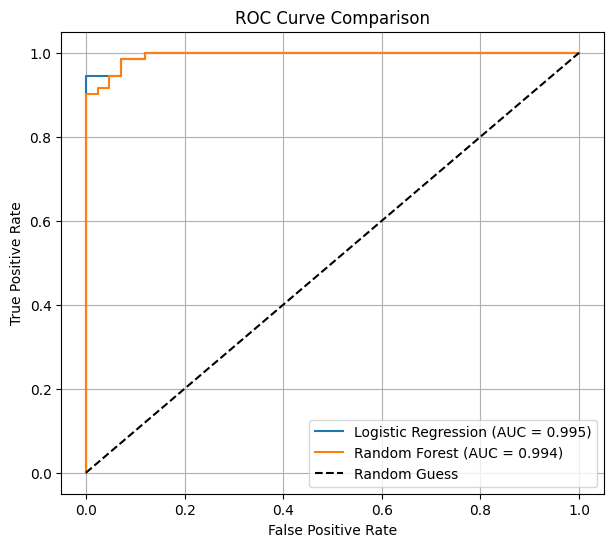

In [5]:
plt.figure(figsize=(7,6))

plt.plot(log_fpr, log_tpr, label=f"Logistic Regression (AUC = {log_auc:.3f})")
plt.plot(rf_fpr, rf_tpr, label=f"Random Forest (AUC = {rf_auc:.3f})")

# Random baseline
plt.plot([0,1], [0,1], "k--", label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(True)
plt.show()

---